# Tutorial: Variational Quantum Eigensolver with Bayesian Optimisation (BO)  
### Estimating the Ground State Energy of the Hydrogen Molecule ($H_2$)

In this hands-on tutorial, we demonstrate how to implement Bayesian Optimisation (BO) to estimate the ground state energy $E_0$ of the hydrogen molecule ($H_2$). We explore two different approaches:

1.    GP Eigenvalue – A single surrogate model is used to directly estimate the eigenvalue (i.e., the ground state energy).

2.    GPs Observables – Multiple surrogate models are used to estimate individual observables. These are then combined to reconstruct the eigenvalue.

Both approaches aim to efficiently find the optimal parameters for the Variational Quantum Eigensolver (VQE) using BO.

We begin by importing the necessary libraries. In particular, pay attention to:

-    create_circuit_ansatz: A customizable function to generate the parameterized quantum circuit (ansatz).

-    BayesianOptimiserEigenvalue and BayesianOptimiserObservables: Classes implementing the two BO strategies outlined above.

Note: The hyperparameters that you will find in this notebook have not been optimised.

In [1]:
import numpy as np
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(os.path.join(parent_dir, 'src/utils/'))
sys.path.append(os.path.join(parent_dir, 'src/bo/'))
import json
from functions import CustomEncoder
from circuit_utils import create_circuit_ansatz
from optimisation_bo import BayesianOptimiserEigenvalue, BayesianOptimiserObservables

from scipy.linalg import eigh
from qiskit.quantum_info import Statevector
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.operators import PolynomialTensor
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit.circuit.library import TwoLocal

## Setting Up the Molecular Hamiltonian for $H_2$

In the next section, we define the $H_2$ molecule and construct its corresponding qubit Hamiltonian, which will later be used in the VQE algorithm.

1. Molecular Setup: <br /> 
    We use the PySCFDriver from Qiskit Nature to define the $H_2$ molecule at an internuclear distance of 0.735 Å, with a minimal basis set (sto3g), zero charge, and zero spin.
2. Hamiltonian Construction: <br /> 
    Running the driver yields the electronic structure problem, from which we extract the second-quantized electronic Hamiltonian.

3. Mapping to Qubits: <br /> 
    The fermionic Hamiltonian is mapped to a qubit Hamiltonian using the Jordan-Wigner transformation, enabling its simulation on a quantum computer.

4. Including Nuclear Repulsion Energy: <br /> 
    We add the nuclear repulsion energy to the electronic part of the Hamiltonian to obtain the total molecular energy. The Hamiltonian is then updated and remapped to qubits.

This qubit Hamiltonian, H, will serve as the objective function in our variational quantum algorithm.

In [2]:
#Setting up the H2 molecule
driver = PySCFDriver(
    atom="H 0 0 0; H 0 0 0.735",
    basis="sto3g",
    charge=0,
    spin=0,
    unit=DistanceUnit.ANGSTROM
)


problem = driver.run()

#Obtaining the Hamiltonian
hamiltonian = problem.hamiltonian
hamiltonian.electronic_integrals.alpha += PolynomialTensor({"": hamiltonian.nuclear_repulsion_energy})

mapper = JordanWignerMapper()
second_q_op = hamiltonian.second_q_op()
H = mapper.map(second_q_op)



## Building the Variational Ansatz for the $H_2$ Molecule

In this section, we define the quantum circuit that prepares the trial wavefunction used in the VQE.

1.  Initial State – Hartree-Fock:
    We prepare the Hartree-Fock (HF) state using the HartreeFock class, which represents the mean-field approximation of the ground state. It is constructed based on:

    -    The number of spatial orbitals

    -    The number of particles (electrons)

    -    The chosen qubit mapping (Jordan-Wigner in this case)

2.  Ansatz Options:
    Two variational forms are considered for preparing the quantum state:

    -    UCCSD (Unitary Coupled Cluster with Singles and Doubles): A chemically inspired ansatz tailored to quantum chemistry problems.

    -    TwoLocal Ansatz: A hardware-efficient, generic ansatz composed of parameterized single-qubit rotations (ry) and entangling gates (cz).


3.  Visualization and Parameters:

    -    The number of qubits required is extracted from the ansatz.

    -    We print and visualize the initial Hartree-Fock state.

    -    We visualize the parameterized circuit (ansatz) using a helper function create_circuit_ansatz, initialized with zero parameters.

This variational form will be optimized to minimize the expectation value of the qubit Hamiltonian, leading us to the ground state energy of the molecule.


Initial state: Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j],
            dims=(2, 2, 2, 2))
Circuit Ansatz


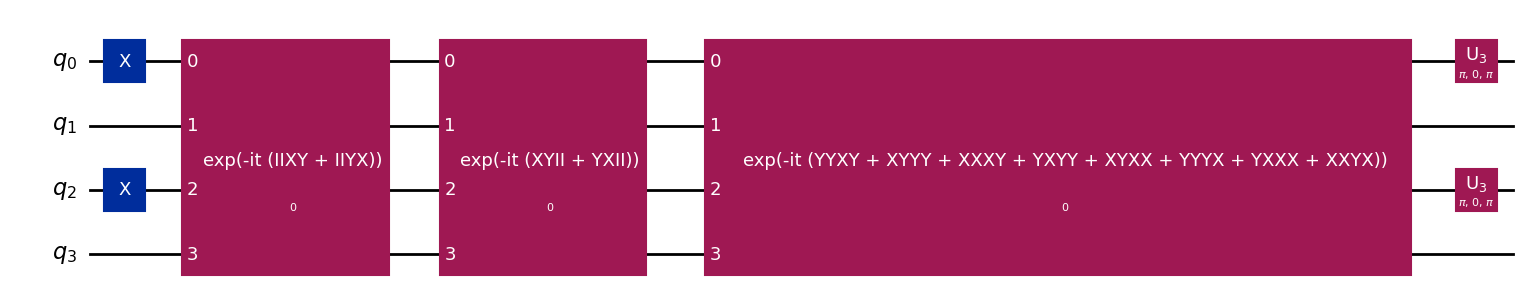

In [3]:
# Set up the initial state and, the UCCSD or TwoLocal ansatz for H2
num_spatial_orbitals = problem.num_spatial_orbitals
num_particles = problem.num_particles
mapper = JordanWignerMapper()

initial_state = HartreeFock(
    num_spatial_orbitals,
    num_particles,
    mapper
)

ansatz = UCCSD(num_spatial_orbitals=num_spatial_orbitals, num_particles=num_particles, qubit_mapper=mapper, initial_state=initial_state)
#ansatz = TwoLocal(H.num_qubits, rotation_blocks="ry", entanglement_blocks="cz")
num_qubits = ansatz.num_qubits

print('Initial state:', Statevector.from_instruction(initial_state))
initial_circuit = ansatz.decompose()
print('Circuit Ansatz')
n_thetas = ansatz.num_parameters
circ_visualization = create_circuit_ansatz(ansatz, np.zeros(n_thetas)[np.newaxis,:], initial_state)
circ_visualization.decompose().draw('mpl')


## Exact Diagonalization of the Qubit Hamiltonian

Before applying VQE, we compute the exact ground state energy of the system using classical diagonalization. This serves as a reference to evaluate the performance of our variational method.


In [4]:
eigenvalues, eigenvectors = eigh(H.to_matrix())
ground_state_energy = np.min(eigenvalues)
ground_state = eigenvectors[:, np.argmin(eigenvalues)]
print(f"Ground state energy: {ground_state_energy}")

Ground state energy: -1.1373060357534004


## Optimising the Ground State Energy – GP Eigenvalue Approach


In this section, we perform VQE using Bayesian Optimisation with a single surrogate model, referred to as the GP Eigenvalue approach.


In [5]:
hyperparams = {
    'num_iters': 200, #Number of iteration = Number of angles sets to test
    'training_iter': 10,
    'learning_rate': 0.1,
    'initial_lengthscale': 0.9,
    'initial_noise': 1e-8,
    'initial_output_scale': 1,
    'verbose': 0,
    'beta': 0.1,
    'raw_samples':1000,
    'num_restarts':5,
    'scaler_target':None
    }  

param_bounds = [[0, 2 * np.pi] for _ in range(n_thetas)]
n_run = 2

metrics = {'history_best_eigenvalue_runs':[],
           'history_best_thetas_runs':[],
           'best_eigenvalue_runs':[],
           'best_thetas_runs': []}
for iter_run in range(n_run):
    print('run ', iter_run+1)
        
    # Initialize Bayesian Optimiser
    optimiser = BayesianOptimiserEigenvalue(
        circuit=create_circuit_ansatz,
        ansatz=ansatz,
        n_thetas=n_thetas,
        initial_state=initial_state,
        H=H,
        param_bounds=param_bounds,
        num_qubits=num_qubits,
        num_initial_samples=1,
        hyperparams=hyperparams,
        )

    # Run optimisation
    optimal_params, eigenvalue, info = optimiser.optimise()

    print("Optimal parameters found:", optimal_params)
    print("Optimal eigenvalue found:", eigenvalue)

    log_best_thetas = np.array(info['best_log']['thetas'] )
    log_best_eigenvalue = np.array(info['best_log']['eigenvalue'] )

    metrics['history_best_thetas_runs'].append(log_best_thetas)
    metrics['history_best_eigenvalue_runs'].append(log_best_eigenvalue)
    metrics['best_thetas_runs'].append(optimal_params)
    metrics['best_eigenvalue_runs'].append(eigenvalue)
    
    

run  1
Optimal parameters found: [1.57058443 4.71261855 3.14158775]
Optimal eigenvalue found: -0.9342470904713661
run  2
Optimal parameters found: [0.         6.28318531 1.57079108]
Optimal eigenvalue found: -0.9342472328625411


We can save our results for later analysis

In [6]:

if True:
    name_output_file = "example_results_H2_bo_eigenvalue"
    
    data_plot = {'history_best_eigenvalue_runs':metrics['history_best_eigenvalue_runs'],
                'best_thetas_runs': metrics['best_thetas_runs'],
                'best_eigenvalue_runs':metrics['best_eigenvalue_runs']} 
    with open("../results/" + name_output_file + ".json", "w") as outfile: 
        json.dump(data_plot, outfile, cls=CustomEncoder)


We plot the results

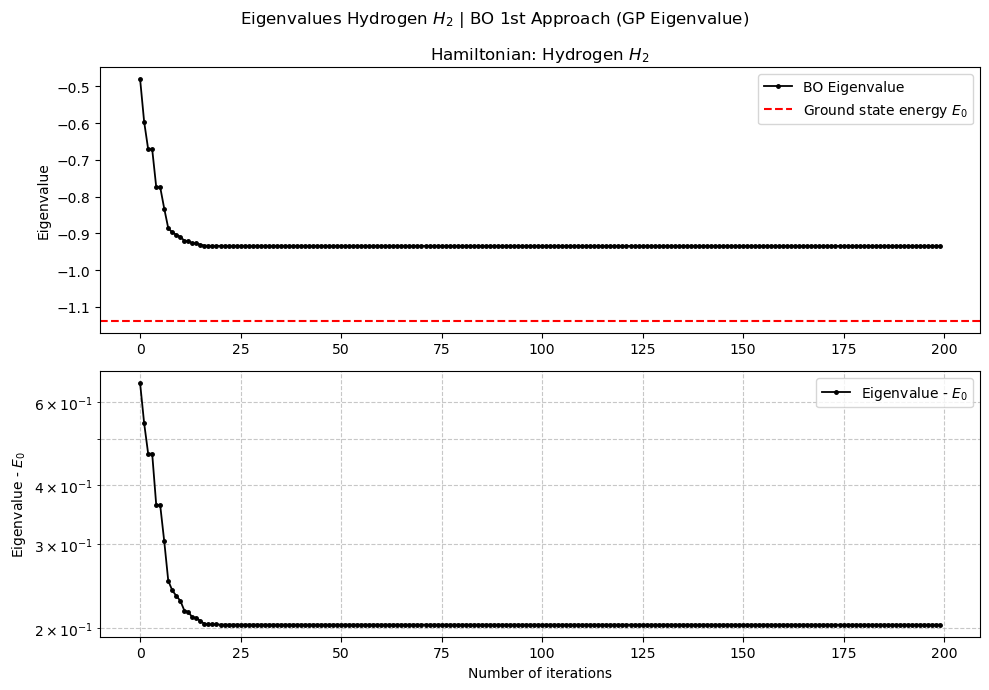

Mean Best Eigenvalue:  -0.9342471616669537


In [7]:
import matplotlib.pylab as plt

fig, ax = plt.subplots(2,1,figsize=(10,7), facecolor='white', constrained_layout = True, sharex=False, sharey=False)

plt.suptitle('Eigenvalues Hydrogen $H_{2}$ | BO 1st Approach (GP Eigenvalue)')

ax[0].set_title(r'Hamiltonian: Hydrogen $H_{2}$')
ax[0].plot(np.arange(hyperparams['num_iters'],dtype=int), np.mean(metrics['history_best_eigenvalue_runs'],0), '-o', linewidth=1.3, color='k', markersize=2.5, label = 'BO Eigenvalue')
ax[0].axhline(ground_state_energy, linestyle='--',color='r', label='Ground state energy $E_{0}$')

ax[1].plot(np.arange(hyperparams['num_iters'],dtype=int), np.mean(metrics['history_best_eigenvalue_runs'],0) - ground_state_energy, '-o', linewidth=1.3, color='k', markersize=2.5, label = 'Eigenvalue - $E_{0}$')
ax[1].set_yscale('log')
ax[0].set_ylabel('Eigenvalue')
ax[1].set_ylabel('Eigenvalue - $E_{0}$')
ax[1].set_xlabel('Number of iterations')

ax[0].legend(loc='upper right')
ax[1].legend(loc='upper right')
plt.grid(True, which='both', axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend()
plt.show()
print('Mean Best Eigenvalue: ', np.mean(metrics['best_eigenvalue_runs']))

## Optimising the Ground State Energy – GPs Observables Approach

This section introduces an alternative strategy for estimating the ground state energy using Bayesian Optimisation with multiple surrogate models, known as the GPs Observables approach.

In [8]:
hyperparams = {
    'num_iters': 200, #Number of iteration = Number of angles sets to test
    'training_iter': 10,
    'learning_rate': 0.1,
    'initial_lengthscale': 0.9,
    'initial_noise': 1e-8,
    'initial_output_scale': 1,
    'verbose': 0,
    'beta': 0.1,
    'raw_samples':1000,
    'num_restarts':5,
    'scaler_target':None
    }   

n_run = 2

param_bounds = [[0, 2 * np.pi] for _ in range(n_thetas)]
metrics = {'history_best_eigenvalue_runs':[],
           'history_best_thetas_runs':[],
           'best_eigenvalue_runs':[],
           'best_thetas_runs': []}
for iter_run in range(n_run):
    print('run ', iter_run+1)
        
    optimiser = BayesianOptimiserObservables(
        circuit=create_circuit_ansatz,
        ansatz=ansatz,
        n_thetas=n_thetas,
        initial_state=initial_state,
        H=H,
        param_bounds=param_bounds,
        num_qubits=num_qubits,
        num_initial_samples=1,
        hyperparams=hyperparams,
        )

    # Run optimisation
    optimal_params, eigenvalue, info = optimiser.optimise()

    print("Optimal parameters found:", optimal_params)
    print("Optimal eigenvalue found:", eigenvalue)

    log_best_thetas = np.array(info['best_log']['thetas'] )
    log_best_eigenvalue = np.array(info['best_log']['eigenvalue'] )

    metrics['history_best_thetas_runs'].append(log_best_thetas)
    metrics['history_best_eigenvalue_runs'].append(log_best_eigenvalue)
    metrics['best_thetas_runs'].append(optimal_params)
    metrics['best_eigenvalue_runs'].append(eigenvalue)



run  1
Optimal parameters found: [6.28318531 3.1418122  4.71317779]
Optimal eigenvalue found: -0.9342470292195204
run  2
Optimal parameters found: [0.         0.         1.57079832]
Optimal eigenvalue found: -0.9342472328675956


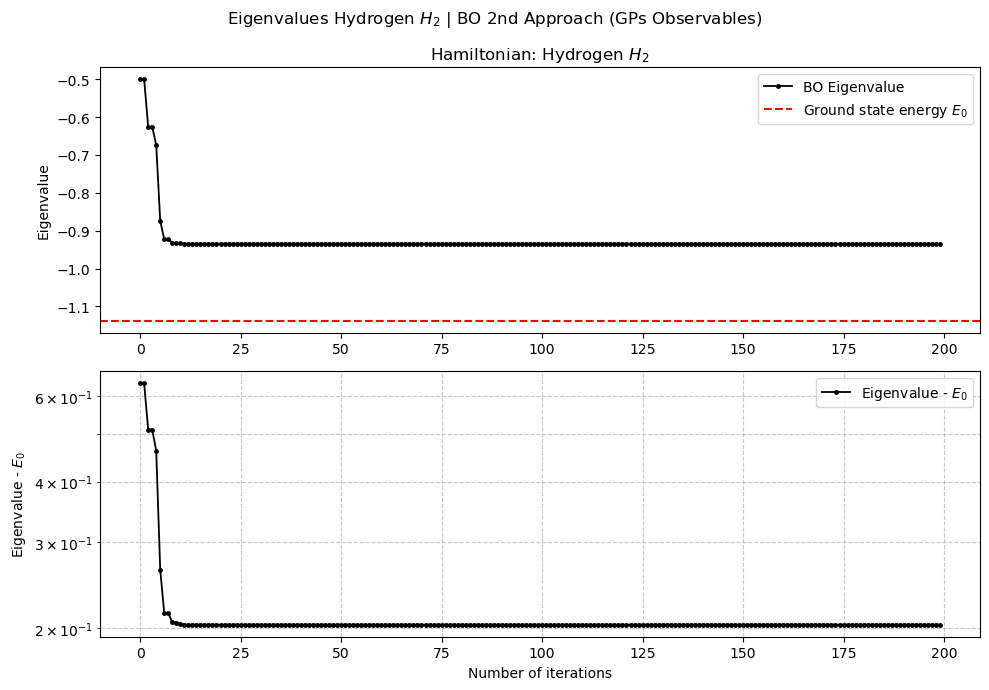

Mean Best Eigenvalue:  -0.934247131043558


In [9]:
import matplotlib.pylab as plt

fig, ax = plt.subplots(2,1,figsize=(10,7), facecolor='white', constrained_layout = True, sharex=False, sharey=False)

plt.suptitle('Eigenvalues Hydrogen $H_{2}$ | BO 2nd Approach (GPs Observables)')

ax[0].set_title(r'Hamiltonian: Hydrogen $H_{2}$')
ax[0].plot(np.arange(hyperparams['num_iters'],dtype=int), np.mean(metrics['history_best_eigenvalue_runs'],0), '-o', linewidth=1.3, color='k', markersize=2.5, label = 'BO Eigenvalue')
ax[0].axhline(ground_state_energy, linestyle='--',color='r', label='Ground state energy $E_{0}$')

ax[1].plot(np.arange(hyperparams['num_iters'],dtype=int), np.mean(metrics['history_best_eigenvalue_runs'],0) - ground_state_energy, '-o', linewidth=1.3, color='k', markersize=2.5, label = 'Eigenvalue - $E_{0}$')
ax[1].set_yscale('log')
ax[0].set_ylabel('Eigenvalue')
ax[1].set_ylabel('Eigenvalue - $E_{0}$')
ax[1].set_xlabel('Number of iterations')

ax[0].legend(loc='upper right')
ax[1].legend(loc='upper right')
plt.grid(True, which='both', axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.legend()
plt.show()
print('Mean Best Eigenvalue: ', np.mean(metrics['best_eigenvalue_runs']))